In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\INTEL\OneDrive\Desktop\Coding\MACHINE LEARNING\Machine Learning\Campus Placements Prediction\Placement_Data_Full_Class.csv")

In [3]:
df.head(10)

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.00,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.50,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.00,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.00,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.80,Mkt&Fin,55.50,Placed,425000.0
5,6,M,55.00,Others,49.80,Others,Science,67.25,Sci&Tech,Yes,55.00,Mkt&Fin,51.58,Not Placed,NaN
6,7,F,46.00,Others,49.20,Others,Commerce,79.00,Comm&Mgmt,No,74.28,Mkt&Fin,53.29,Not Placed,NaN
7,8,M,82.00,Central,64.00,Central,Science,66.00,Sci&Tech,Yes,67.00,Mkt&Fin,62.14,Placed,252000.0
8,9,M,73.00,Central,79.00,Central,Commerce,72.00,Comm&Mgmt,No,91.34,Mkt&Fin,61.29,Placed,231000.0
9,10,M,58.00,Central,70.00,Central,Commerce,61.00,Comm&Mgmt,No,54.00,Mkt&Fin,52.21,Not Placed,NaN


In [4]:
df.tail(10)

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
205,206,M,61.00,Others,62.0,Others,Commerce,65.0,Comm&Mgmt,No,62.00,Mkt&Fin,56.81,Placed,250000.0
206,207,M,41.00,Central,42.0,Central,Science,60.0,Comm&Mgmt,No,97.00,Mkt&Fin,53.39,Not Placed,NaN
207,208,M,83.33,Central,78.0,Others,Commerce,61.0,Comm&Mgmt,Yes,88.56,Mkt&Fin,71.55,Placed,300000.0
208,209,F,43.00,Central,60.0,Others,Science,65.0,Comm&Mgmt,No,92.66,Mkt&HR,62.92,Not Placed,NaN
209,210,M,62.00,Central,72.0,Central,Commerce,65.0,Comm&Mgmt,No,67.00,Mkt&Fin,56.49,Placed,216000.0
210,211,M,80.60,Others,82.0,Others,Commerce,77.6,Comm&Mgmt,No,91.00,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.0,Others,Science,72.0,Sci&Tech,No,74.00,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.0,Others,Commerce,73.0,Comm&Mgmt,Yes,59.00,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.0,Others,Commerce,58.0,Comm&Mgmt,No,70.00,Mkt&HR,60.23,Placed,204000.0
214,215,M,62.00,Central,58.0,Others,Science,53.0,Comm&Mgmt,No,89.00,Mkt&HR,60.22,Not Placed,NaN


In [5]:
print('No of rows =',df.shape[0])
print('No of columns =',df.shape[1])

No of rows = 215
No of columns = 15


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [7]:
df.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [8]:
df.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [9]:
df.columns

Index(['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s',
       'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p',
       'status', 'salary'],
      dtype='object')

In [10]:
df['status'].value_counts()

status
Placed        148
Not Placed     67
Name: count, dtype: int64

# Data Encoding

In [11]:
df = df.drop(['sl_no','salary'],axis = 1)

In [12]:
df.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed


In [13]:
df['gender'].unique()

array(['M', 'F'], dtype=object)

In [14]:
df['ssc_b'].unique()

array(['Others', 'Central'], dtype=object)

In [15]:
df['hsc_b'].unique()

array(['Others', 'Central'], dtype=object)

In [16]:
df['hsc_s'].unique()

array(['Commerce', 'Science', 'Arts'], dtype=object)

In [17]:
df['degree_t'].unique()

array(['Sci&Tech', 'Comm&Mgmt', 'Others'], dtype=object)

In [18]:
df['specialisation'].unique()

array(['Mkt&HR', 'Mkt&Fin'], dtype=object)

In [19]:
df['workex'].unique()

array(['No', 'Yes'], dtype=object)

In [20]:
df['status'].unique()

array(['Placed', 'Not Placed'], dtype=object)

In [21]:
df['gender'] = df['gender'].map({'M':1, 'F':0})

In [22]:
df['ssc_b'] = df['ssc_b'].map({'Central':1, 'Others':0})

In [23]:
df['hsc_b'] = df['hsc_b'].map({'Central':1, 'Others':0})

In [24]:
df['hsc_s'] = df['hsc_s'].map({'Commerce':1,'Science':2,'Arts':0})

In [25]:
df['degree_t'] = df['degree_t'].map({'Sci&Tech':1,'Comm&Mgmt':2,'Others':0})

In [26]:
df['specialisation'] = df['specialisation'].map({'Mkt&Fin':1, 'Mkt&HR':0})

In [27]:
df['workex'] = df['workex'].map({'Yes':1, 'No':0})

In [28]:
df['status'] = df['status'].map({'Placed':1, 'Not Placed':0})

In [29]:
df.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,1,67.00,0,91.00,0,1,58.00,1,0,55.0,0,58.80,1
1,1,79.33,1,78.33,0,2,77.48,1,1,86.5,1,66.28,1
2,1,65.00,1,68.00,1,0,64.00,2,0,75.0,1,57.80,1
3,1,56.00,1,52.00,1,2,52.00,1,0,66.0,0,59.43,0
4,1,85.80,1,73.60,1,1,73.30,2,0,96.8,1,55.50,1


# Training model & prediction

In [30]:
x = df.drop(['status'], axis = 1)
y = df['status']

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.25, random_state = 42)

In [32]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train,y_train)

svc = SVC()
svc.fit(x_train, y_train)

knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

rf = RandomForestClassifier()
rf.fit(x_train, y_train)

gb = GradientBoostingClassifier()
gb.fit(x_train, y_train)

GradientBoostingClassifier()

In [33]:
y_pred1 = lr.predict(x_test)
y_pred2 = svc.predict(x_test)
y_pred3 = knn.predict(x_test)
y_pred4 = dt.predict(x_test)
y_pred5 = rf.predict(x_test)
y_pred6 = gb.predict(x_test)

In [34]:
print("Accuracy score for Logistic Regression:",accuracy_score(y_test,y_pred1))
print("Accuracy score for Support Vector Machine Classifier:",accuracy_score(y_test,y_pred2))
print("Accuracy score for K Neighbors Classifier:",accuracy_score(y_test,y_pred3))
print("Accuracy score for Decision Tree Classifier:",accuracy_score(y_test,y_pred4))
print("Accuracy score for Random Forest Classifier:",accuracy_score(y_test,y_pred5))
print("Accuracy score for GradientBoosting Classifier:",accuracy_score(y_test,y_pred6))

Accuracy score for Logistic Regression: 0.8703703703703703
Accuracy score for Support Vector Machine Classifier: 0.7962962962962963
Accuracy score for K Neighbors Classifier: 0.8148148148148148
Accuracy score for Decision Tree Classifier: 0.8148148148148148
Accuracy score for Random Forest Classifier: 0.8148148148148148
Accuracy score for GradientBoosting Classifier: 0.8148148148148148


# Visualizing the performances of the models

In [35]:
data = pd.DataFrame({
                    'Models':['LR',"SVC",'KNN','DT','RF','GB'],
                    'ACC':[accuracy_score(y_test,y_pred1)*100,
                           accuracy_score(y_test,y_pred2)*100,
                           accuracy_score(y_test,y_pred3)*100,
                           accuracy_score(y_test,y_pred4)*100,
                           accuracy_score(y_test,y_pred5)*100,
                           accuracy_score(y_test,y_pred6)*100 
                    ]})

In [36]:
data

,Models,ACC
0,LR,87.037037
1,SVC,79.629630
2,KNN,81.481481
3,DT,81.481481
4,RF,81.481481
5,GB,81.481481


<Axes: xlabel='Models', ylabel='ACC'>

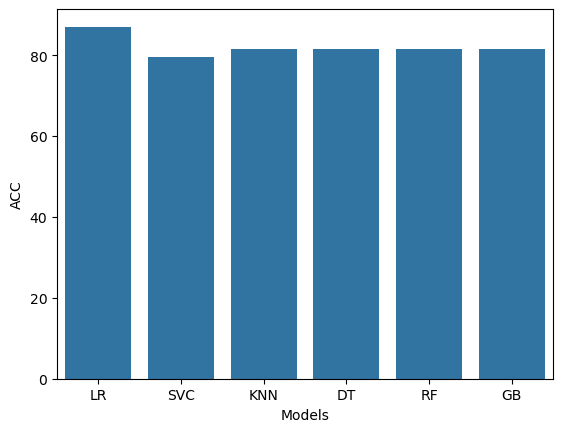

In [37]:
sns.barplot(x = data['Models'],y = data['ACC'])

# Training the best model (GradientBoosting) on entire dataset

In [38]:
new_data = pd.DataFrame({
    'gender':1,
    'ssc_p':62.0,
    'ssc_b':0,
    'hsc_p':91.0,
    'hsc_b':1,
    'hsc_s':1,
    'degree_p':85.0,
    'degree_t':2,
    'workex':0,
    'etest_p':0,
    'specialisation':1,
    'mba_p':58.8
},index = [0])

In [39]:
lr = LogisticRegression(max_iter = 1000)
lr.fit(x,y)

LogisticRegression(max_iter=1000)

In [40]:
p = lr.predict(new_data)
prob = lr.predict_proba(new_data)
if p == 1:
    print(f"Placed with probability: {prob[0][1]:.2f}")
else:
    print("Not placed")

Placed with probability: 1.00


# Saving model using joblib

In [41]:
import joblib

In [42]:
joblib.dump(lr,'campus_placement_model')

['campus_placement_model']

In [43]:
model = joblib.load('campus_placement_model')

In [44]:
model.predict(new_data)

array([1])